# 1 month salt budget test for ACCESS-OM2-01

Currently this salt budget does **not close**. Semi-closed? Get second opinion.  
This is from the experiment at https://github.com/julia-neme/ssp126_sofia_experiments/tree/access-ssp126-sofia. 

In [2]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [3]:
lat_slice = slice(-79,-59)

# Importing data
paths_2 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output040/ocean/ocean.nc'))
paths_1 = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output040/ocean/ocean_month.nc'))

In [4]:
# Time variant variables
def preprocess_1(ds):
    ds = ds[['pme_river','runoff','evap','pme_correct']].sel(yt_ocean=lat_slice)
    return ds

def preprocess_2(ds):
    ds = ds[['salt','salt_advection','salt_submeso','salt_tendency','salt_vdiffuse_impl','salt_nonlocal_KPP','salt_rivermix','salt_eta_smooth']].sel(yt_ocean=lat_slice)
    return ds

data_1 = xr.open_mfdataset(paths_1, preprocess = preprocess_1, chunks = 'auto',decode_times=False)
data_2 = xr.open_mfdataset(paths_2, preprocess = preprocess_2, chunks = 'auto',decode_times=False)

In [5]:
lhs_salt = {
    'salt_tendency': data_2.salt_tendency
}

rhs_salt = {
    # Advection
    'advection': data_2.salt_advection,
    'submeso': data_2.salt_submeso,

    # Diffusion / mixing + Surface & boundary forcing
    'vertical_diff': data_2.salt_vdiffuse_impl, # this includes surface salt flux
    'nonlocal_KPP': data_2.salt_nonlocal_KPP,
    'river_mix': data_2.salt_rivermix,
    'eta_smooth': data_2.salt_eta_smooth, # surface smoother for salt
}

In [6]:
data_2.salt_eta_smooth

<xarray.DataArray 'salt_eta_smooth' (time: 1, yt_ocean: 460, xt_ocean: 3600)> Size: 7MB
dask.array<getitem, shape=(1, 460, 3600), dtype=float32, chunksize=(1, 460, 3600), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) float64 8B 3.666e+03
  * yt_ocean  (yt_ocean) float64 4kB -79.0 -78.95 -78.91 ... -59.08 -59.03
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Attributes:
    long_name:      surface smoother for salt
    units:          kg/(sec*m^2)
    valid_range:    [-100000.  100000.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

At the moment taking `time`=0 to just look at first month - but I'm unsure this is still giving me the right evolution over time that I am looking for.

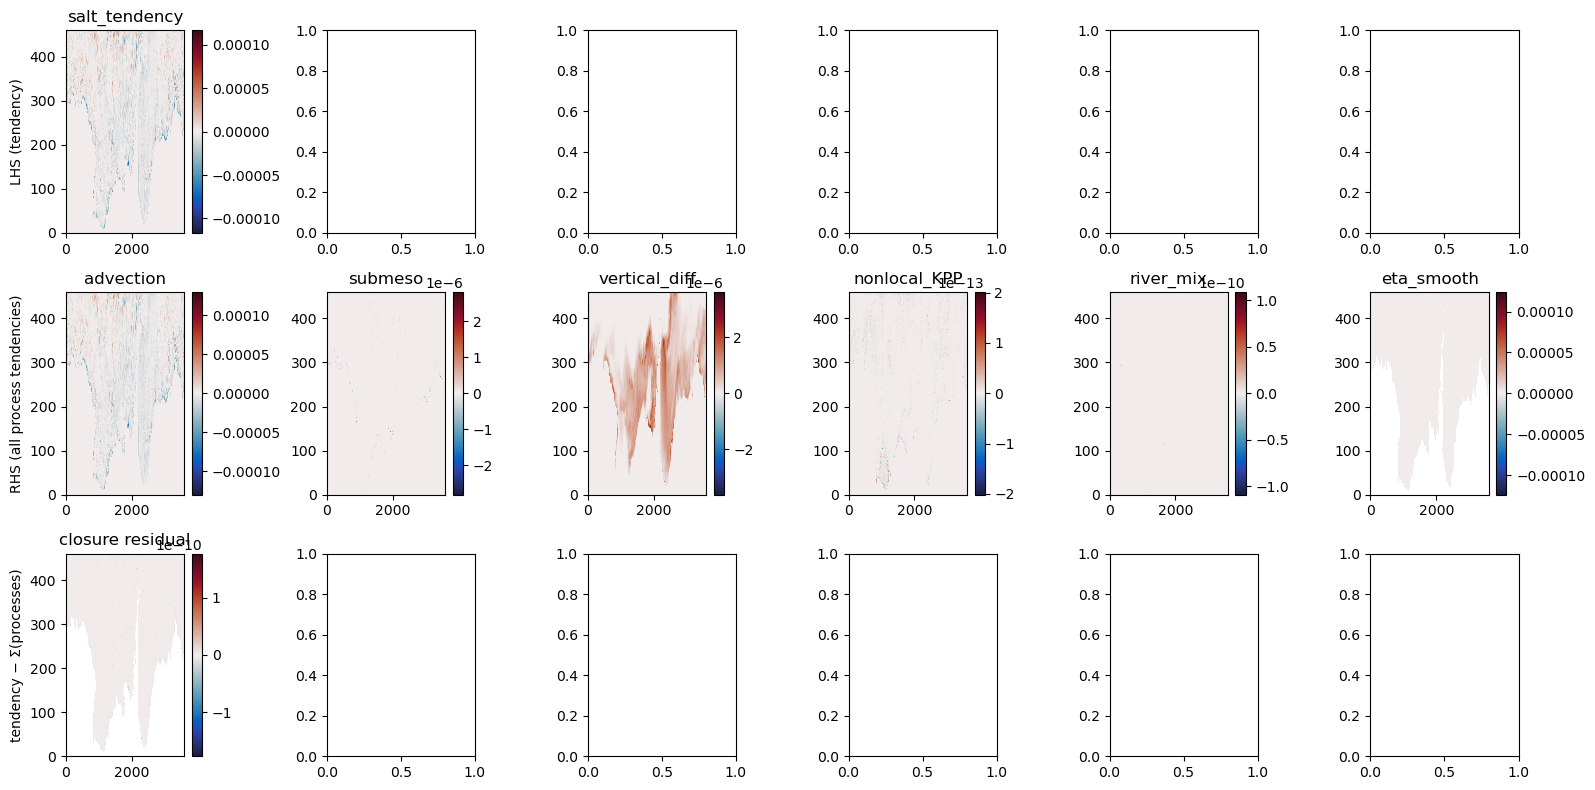

In [7]:
zdim = 'st_ocean'  # MOM5 vertical grid dimension

fig, ax = plt.subplots(
    figsize=(16, 8),
    nrows=3,
    ncols=max(len(lhs_salt), len(rhs_salt))
)
ax = ax.reshape(3, -1)  # flatten for consistent indexing

# -----------------------
# LHS terms
# -----------------------
for i, (name, da) in enumerate(lhs_salt.items()):
    da2d = da.sum(zdim).squeeze()
    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)
    da2d = da2d.compute()
    vmax = np.nanmax(np.abs(da2d))
    im = ax[0, i].pcolormesh(da2d, cmap=cm.cm.balance,vmax = vmax,vmin = -vmax)
    plt.colorbar(im, ax=ax[0, i])
    ax[0, i].set_title(name)

# -----------------------
# RHS terms
# -----------------------
for i, (name, da) in enumerate(rhs_salt.items()):
    if zdim in da.dims:
        da2d = da.sum(zdim)
    else:
        da2d = da
        
    da2d = da2d.squeeze()
    
    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)
    da2d = da2d.compute()
    vmax = np.nanmax(np.abs(da2d))
    im = ax[1, i].pcolormesh(da2d,cmap=cm.cm.balance,vmax = vmax,vmin = -vmax)
    plt.colorbar(im, ax=ax[1, i])
    ax[1, i].set_title(name)

# -----------------------
# Closure residual
# -----------------------
lhs_total = data_2.salt_tendency

# rhs_total = (
#     data_2.salt_advection
#     + data_2.salt_submeso
#     + data_2.salt_vdiffuse_impl
#     + data_2.salt_nonlocal_KPP
#     + data_2.salt_rivermix
#     + data_2.salt_eta_smooth
# )

# residual = (lhs_total - rhs_total).sum(zdim).squeeze()

# Sum only 3D terms
lhs_col = lhs_total.sum(zdim)

rhs_col = (
    data_2.salt_advection.sum(zdim)
    + data_2.salt_submeso.sum(zdim)
    + data_2.salt_vdiffuse_impl.sum(zdim)
    + data_2.salt_nonlocal_KPP.sum(zdim)
    + data_2.salt_rivermix.sum(zdim)
)

# Now add the 2D correction ONCE
rhs_col = rhs_col + data_2.salt_eta_smooth

residual = lhs_col - rhs_col

if 'time' in residual.dims:
    residual = residual.isel(time=0)

residual = residual.compute()
vmax = np.abs(residual).max()

im = ax[2, 0].pcolormesh(
    residual, cmap=cm.cm.balance, vmin=-vmax, vmax=vmax
)
plt.colorbar(im, ax=ax[2, 0])
ax[2, 0].set_title('closure residual')


# -----------------------
# Row labels
# -----------------------
ax[0, 0].set_ylabel('LHS (tendency)')
ax[1, 0].set_ylabel('RHS (all process tendencies)')
ax[2, 0].set_ylabel('tendency − Σ(processes)')

plt.tight_layout()


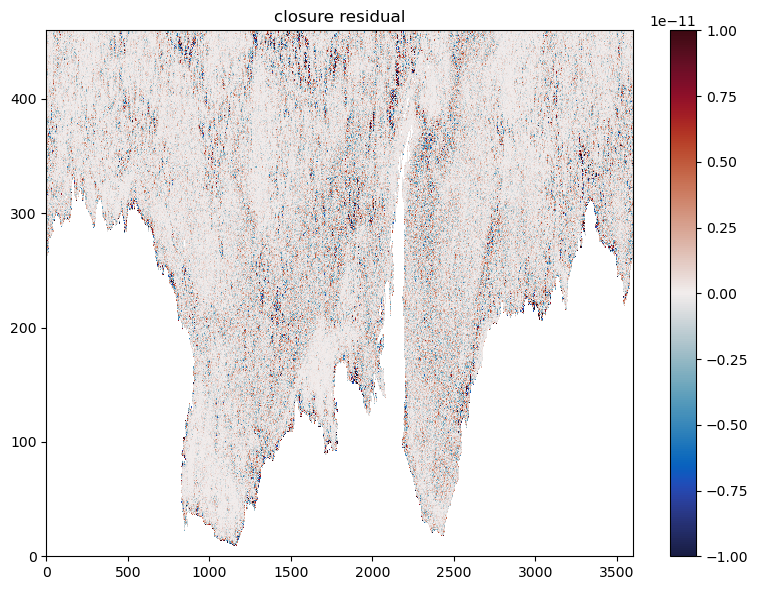

In [8]:
# Plotting just the residual

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.pcolormesh(
    residual,
    cmap=cm.cm.balance,
    vmin=-1e-11,
    vmax=1e-11
)

plt.colorbar(im, ax=ax)
ax.set_title('closure residual')

plt.tight_layout()

#### Checking if we have closure:   
We are told that for the budget to be considered “closed” the difference between the LHS and RHS should be approximately 12 orders of magnitude smaller than the contributing terms. 

In [9]:
# Note residual = (lhs_total - rhs_total).sum(zdim).squeeze()
residual

<xarray.DataArray (yt_ocean: 460, xt_ocean: 3600)> Size: 7MB
array([[           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       ...,
       [ 2.2737368e-13,  9.0949470e-13, -9.0949470e-13, ...,
        -2.2737368e-13,  4.5474735e-13,  2.2737368e-13],
       [ 2.2737368e-13, -6.8212103e-13,  2.2737368e-13, ...,
         2.2737368e-13,  2.2737368e-13, -4.5474735e-13],
       [ 2.2737368e-13,  2.2737368e-13,  4.5474735e-13, ...,
         4.5474735e-13,  4.5474735e-13, -6.8212103e-13]], dtype=float32)
Coordinates:
  * yt_ocean  (yt_ocean) float64 4kB -79.0 -78.95 -78.91 ... -59.08 -59.03
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
    time      float64 8B 3.666e+03

In [10]:
residual.max().compute()

<xarray.DataArray ()> Size: 8B
array(1.00953912e-10)
Coordinates:
    time     float64 8B 3.666e+03

In [11]:
residual.min().compute()

<xarray.DataArray ()> Size: 8B
array(-1.76441972e-10)
Coordinates:
    time     float64 8B 3.666e+03

So maybe closed???

## Attempting to close the budget

In [12]:
from gsw import SA_from_SP, p_from_z

Checking if the salinity restoring correction balances the budget. Need to first convert pme_correct into a salt flux. 

In [13]:
restoring_FW_flux = data_1.pme_correct
SSS_prac = data_2.salt

In [14]:
# stuff needed for absolute salinity conversion:
st_ocean = data_2.st_ocean
yt_ocean = data_2.yt_ocean
xt_ocean = data_2.xt_ocean
depth_tile = -(yt_ocean*0+1)*st_ocean[0].values

pressure = xr.DataArray(p_from_z(depth_tile,yt_ocean))
pressure

<xarray.DataArray 'yt_ocean' (yt_ocean: 460)> Size: 4kB
array([0.54705096, 0.54705016, 0.54704935, 0.54704854, 0.54704773,
       0.54704692, 0.5470461 , 0.54704528, 0.54704446, 0.54704364,
       0.54704281, 0.54704198, 0.54704114, 0.54704031, 0.54703947,
       0.54703862, 0.54703778, 0.54703693, 0.54703608, 0.54703522,
       0.54703437, 0.54703351, 0.54703265, 0.54703178, 0.54703091,
       0.54703004, 0.54702917, 0.54702829, 0.54702741, 0.54702653,
       0.54702564, 0.54702475, 0.54702386, 0.54702296, 0.54702207,
       0.54702117, 0.54702026, 0.54701936, 0.54701845, 0.54701754,
       0.54701662, 0.54701571, 0.54701479, 0.54701386, 0.54701294,
       0.54701201, 0.54701108, 0.54701015, 0.54700921, 0.54700827,
       0.54700733, 0.54700638, 0.54700543, 0.54700448, 0.54700353,
       0.54700257, 0.54700161, 0.54700065, 0.54699968, 0.54699872,
       0.54699774, 0.54699677, 0.54699579, 0.54699482, 0.54699383,
       0.54699285, 0.54699186, 0.54699087, 0.54698988, 0.54698888,
       0.54698788, 0.54698688, 0.54698588, 0.54698487, 0.54698386,
       0.54698285, 0.54698183, 0.54698081, 0.54697979, 0.54697877,
       0.54697774, 0.54697671, 0.54697568, 0.54697465, 0.54697361,
       0.54697257, 0.54697153, 0.54697048, 0.54696943, 0.54696838,
       0.54696733, 0.54696627, 0.54696521, 0.54696415, 0.54696309,
       0.54696202, 0.54696095, 0.54695988, 0.5469588 , 0.54695772,
...
       0.54659049, 0.54658872, 0.54658694, 0.54658515, 0.54658337,
       0.54658157, 0.54657978, 0.54657797, 0.54657617, 0.54657435,
       0.54657254, 0.54657071, 0.54656889, 0.54656705, 0.54656522,
       0.54656337, 0.54656153, 0.54655968, 0.54655782, 0.54655596,
       0.54655409, 0.54655222, 0.54655034, 0.54654846, 0.54654657,
       0.54654468, 0.54654278, 0.54654088, 0.54653897, 0.54653706,
       0.54653514, 0.54653321, 0.54653129, 0.54652935, 0.54652741,
       0.54652547, 0.54652352, 0.54652157, 0.54651961, 0.54651764,
       0.54651568, 0.5465137 , 0.54651172, 0.54650974, 0.54650775,
       0.54650575, 0.54650375, 0.54650174, 0.54649973, 0.54649771,
       0.54649569, 0.54649367, 0.54649163, 0.5464896 , 0.54648755,
       0.5464855 , 0.54648345, 0.54648139, 0.54647933, 0.54647726,
       0.54647518, 0.5464731 , 0.54647102, 0.54646893, 0.54646683,
       0.54646473, 0.54646262, 0.54646051, 0.54645839, 0.54645627,
       0.54645414, 0.546452  , 0.54644986, 0.54644772, 0.54644557,
       0.54644341, 0.54644125, 0.54643908, 0.54643691, 0.54643473,
       0.54643255, 0.54643036, 0.54642817, 0.54642597, 0.54642376,
       0.54642155, 0.54641933, 0.54641711, 0.54641488, 0.54641265,
       0.54641041, 0.54640817, 0.54640592, 0.54640366, 0.5464014 ,
       0.54639913, 0.54639686, 0.54639459, 0.5463923 , 0.54639001])
Coordinates:
  * yt_ocean  (yt_ocean) float64 4kB -79.0 -78.95 -78.91 ... -59.08 -59.03

In [15]:
SSS_prac = SSS_prac.sel(yt_ocean=lat_slice).sel(st_ocean=0,method='nearest')

# convert units to absolute salinity:
SSS_abs = xr.DataArray(SA_from_SP(SSS_prac,pressure,yt_ocean,xt_ocean), coords = [SSS_prac.time, SSS_prac.yt_ocean, SSS_prac.xt_ocean], 
                       dims = ['time','yt_ocean', 'xt_ocean'], name = 'sea surface salinity', 
                       attrs = {'units':'Absolute Salinity (g/kg)'})

In [16]:
restoring_salt_flux = SSS_abs * pme_correct / 1000

NameError: name 'pme_correct' is not defined

In [ ]:
restoring_salt_flux.max().compute()

In [ ]:
restoring_salt_flux.max().compute()

Restoring adds on the order of e-07 on the rhs of `residual = lhs_col - rhs_col`. So we have:
$$\text{residual} = \text{lhs\_col} - (\text{rhs\_col} + \text{salt\_restoring\_flux})$$
$$\text{residual} = \text{lhs\_col} - (\text{rhs\_col} + 10^{-7})$$
$$\text{residual} = \text{lhs\_col} - \text{rhs\_col} - 10^{-7}$$
We know that residual ~ $10^{-10}$. So adding in salt restoring just makes the budget look worse. But, salinity restoring shouldn't even be part of salt budget because the salinity restoring was applied as a freshwater flux in this experiment. So we shouldn't expect it to help the budget anyway. Just a thought experiment. 

## Checking ice thickness issue using old experiments

In [26]:
sit_map_C = xr.open_dataarray('/g/data/g40/kc5856/thesis_figures/data_files/ice_thickness_map_cont_prescribed_ACCESS.nc', chunks = 'auto')

In [27]:
sit_map_C.max().load()

<xarray.DataArray 'hi_m' ()> Size: 4B
array(14.42856, dtype=float32)

In [28]:
sit_map_C.min().load()

<xarray.DataArray 'hi_m' ()> Size: 4B
array(0., dtype=float32)

## Checking meltwater

In [9]:
data_1.runoff

<xarray.DataArray 'runoff' (time: 1, yt_ocean: 460, xt_ocean: 3600)> Size: 7MB
dask.array<getitem, shape=(1, 460, 3600), dtype=float32, chunksize=(1, 460, 3600), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) float64 8B 15.5
  * yt_ocean  (yt_ocean) float64 4kB -79.0 -78.95 -78.91 ... -59.08 -59.03
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
Attributes:
    long_name:      mass flux of liquid river runoff entering ocean
    units:          (kg/m^3)*(m/sec)
    valid_range:    [-1000000.  1000000.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  water_flux_into_sea_water_from_rivers

## Trying again with global domain, not just southern ocean

In [3]:
# Time variant variables
def preprocess_1b(ds):
    ds = ds[['pme_river','runoff','evap','pme_correct']]
    return ds

def preprocess_2b(ds):
    ds = ds[['salt','salt_advection','salt_submeso','salt_tendency','salt_vdiffuse_impl','salt_nonlocal_KPP','salt_rivermix','salt_eta_smooth']]
    return ds

data_1b = xr.open_mfdataset(paths_1, preprocess = preprocess_1b, chunks = 'auto',decode_times=False)
data_2b = xr.open_mfdataset(paths_2, preprocess = preprocess_2b, chunks = 'auto',decode_times=False)

In [4]:
lhs_salt = {
    'salt_tendency': data_2b.salt_tendency
}

rhs_salt = {
    # Advection
    'advection': data_2b.salt_advection,
    'submeso': data_2b.salt_submeso,

    # Diffusion / mixing + Surface & boundary forcing
    'vertical_diff': data_2b.salt_vdiffuse_impl, # this includes surface salt flux
    'nonlocal_KPP': data_2b.salt_nonlocal_KPP,
    'river_mix': data_2b.salt_rivermix,
    'eta_smooth': data_2b.salt_eta_smooth, # surface smoother for salt
}

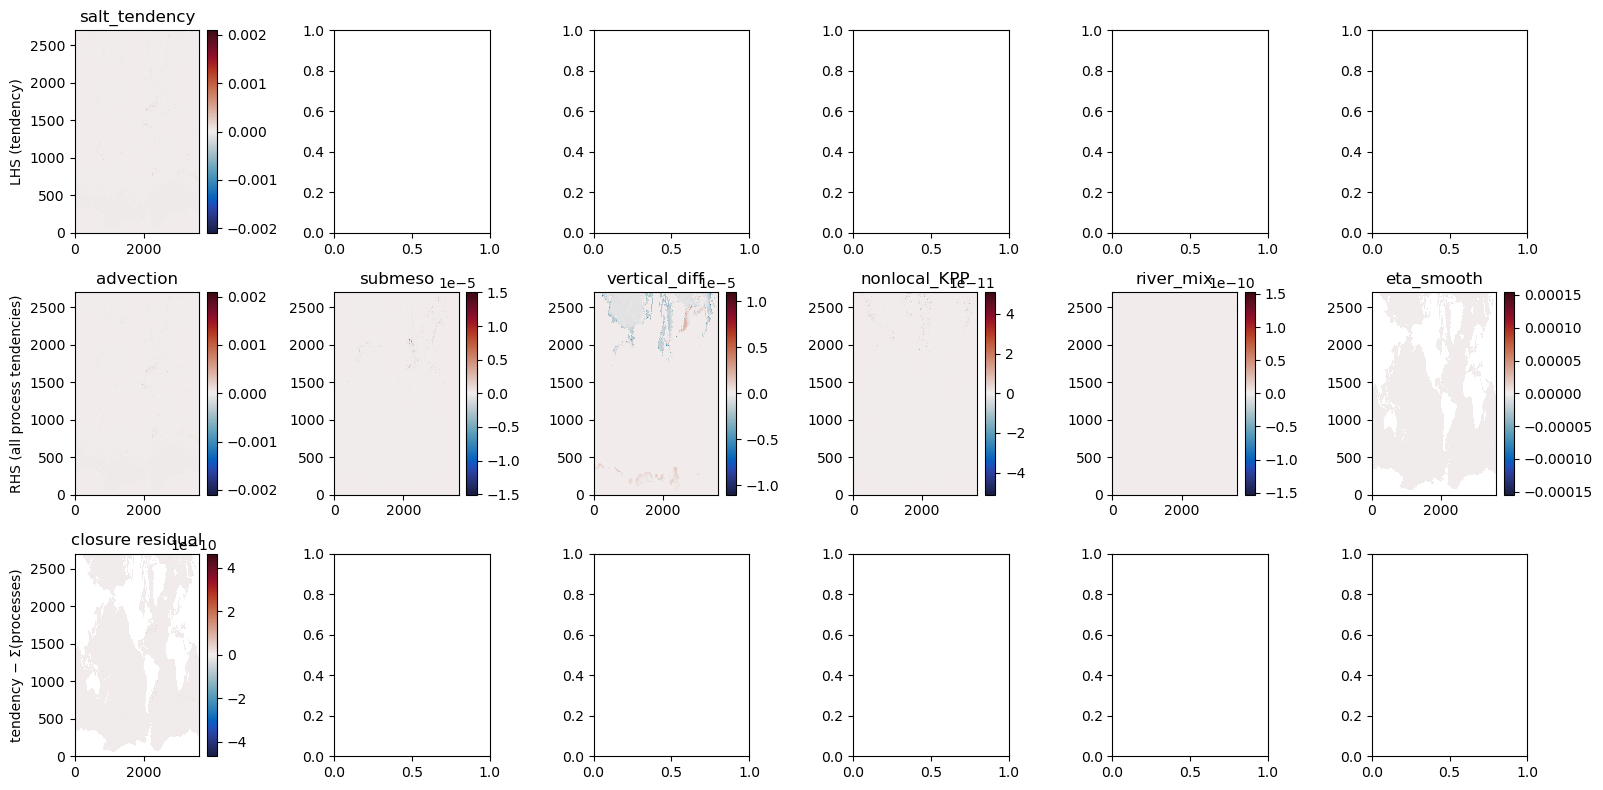

In [6]:
zdim = 'st_ocean'  # MOM5 vertical grid dimension

fig, ax = plt.subplots(
    figsize=(16, 8),
    nrows=3,
    ncols=max(len(lhs_salt), len(rhs_salt))
)
ax = ax.reshape(3, -1)  # flatten for consistent indexing

# -----------------------
# LHS terms
# -----------------------
for i, (name, da) in enumerate(lhs_salt.items()):
    da2d = da.sum(zdim).squeeze()
    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)
    da2d = da2d.compute()
    vmax = np.nanmax(np.abs(da2d))
    im = ax[0, i].pcolormesh(da2d, cmap=cm.cm.balance,vmax = vmax,vmin = -vmax)
    plt.colorbar(im, ax=ax[0, i])
    ax[0, i].set_title(name)

# -----------------------
# RHS terms
# -----------------------
for i, (name, da) in enumerate(rhs_salt.items()):
    if zdim in da.dims:
        da2d = da.sum(zdim)
    else:
        da2d = da
        
    da2d = da2d.squeeze()
    
    if 'time' in da2d.dims:
        da2d = da2d.isel(time=0)
    da2d = da2d.compute()
    vmax = np.nanmax(np.abs(da2d))
    im = ax[1, i].pcolormesh(da2d,cmap=cm.cm.balance,vmax = vmax,vmin = -vmax)
    plt.colorbar(im, ax=ax[1, i])
    ax[1, i].set_title(name)

# -----------------------
# Closure residual
# -----------------------
lhs_total = data_2b.salt_tendency

# Sum only 3D terms
lhs_col = lhs_total.sum(zdim)

rhs_col = (
    data_2b.salt_advection.sum(zdim)
    + data_2b.salt_submeso.sum(zdim)
    + data_2b.salt_vdiffuse_impl.sum(zdim)
    + data_2b.salt_nonlocal_KPP.sum(zdim)
    + data_2b.salt_rivermix.sum(zdim)
)

# Now add the 2D correction ONCE
rhs_col = rhs_col + data_2b.salt_eta_smooth

global_residual = lhs_col - rhs_col

if 'time' in global_residual.dims:
    global_residual = global_residual.isel(time=0)

global_residual = global_residual.compute()
vmax = np.abs(global_residual).max()

im = ax[2, 0].pcolormesh(
    global_residual, cmap=cm.cm.balance, vmin=-vmax, vmax=vmax
)
plt.colorbar(im, ax=ax[2, 0])
ax[2, 0].set_title('closure residual')


# -----------------------
# Row labels
# -----------------------
ax[0, 0].set_ylabel('LHS (tendency)')
ax[1, 0].set_ylabel('RHS (all process tendencies)')
ax[2, 0].set_ylabel('tendency − Σ(processes)')

plt.tight_layout()

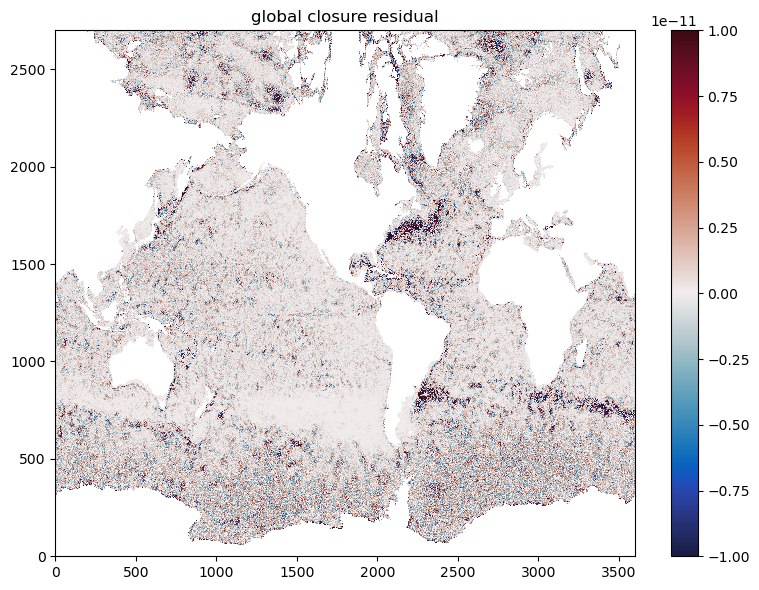

In [7]:
# Plotting just the residual

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.pcolormesh(
    global_residual,
    cmap=cm.cm.balance,
    vmin=-1e-11,
    vmax=1e-11
)

plt.colorbar(im, ax=ax)
ax.set_title('global closure residual')

plt.tight_layout()

In [8]:
global_residual.max().compute()

<xarray.DataArray ()> Size: 8B
array(3.49245965e-10)
Coordinates:
    time     float64 8B 15.5

In [9]:
global_residual.min().compute()

<xarray.DataArray ()> Size: 8B
array(-4.65661287e-10)
Coordinates:
    time     float64 8B 15.5